In [1]:
import matplotlib.pyplot as plt
from plots.mpltoolkit import named_colors, mpl_loc, fancy_legend, load_style_sheet
import numpy as np
import vice
import sys
import os
from databanks.GALAH.DR3 import DR3_GIANTS as dr3giants
dr3giants["absz"] = [abs(z) for z in dr3giants["z"]]
dr3giants = vice.dataframe(dr3giants)
# from databanks.SDSS.DR19 import ASPCAP_GIANTS as dr19giants
# from databanks.SDSS.DR19.ages import roberts2025_cn_age
# dr19giants["absz"] = [abs(z) for z in dr19giants["z"]]
# dr19giants["c_n"] = [a - b for a, b in zip(dr19giants["c_h"], dr19giants["n_h"])]
# dr19giants["age"] = [roberts2025_cn_age(cn, feh) for cn, feh in zip(
#     dr19giants["c_n"], dr19giants["fe_h"])]
# dr19giants = vice.dataframe(dr19giants)
load_style_sheet("papers")
print(sys.version_info[:])

/Users/jamesjohnson/Work/Research/lib/public-dev/VICE/vice/version.py:137: VersionWarning: Using an un-released version of VICE.
  if not self.isreleased: warnings.warn("""\


[4.77435080e+18 4.77432461e+18 4.77432743e+18 4.76025186e+18
 4.76021774e+18 4.76019812e+18 4.76025506e+18 4.76013290e+18
 4.76013738e+18 4.76014834e+18]
[4.66731904e+18 4.66731272e+18 4.66729788e+18 4.66727146e+18
 4.66719916e+18 4.66725516e+18 4.66725840e+18 4.66717882e+18
 4.66725434e+18 4.66719291e+18]
(3, 12, 3, 'final', 0)


In [2]:
print(dr3giants["mwm_cn_age"][:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [3]:
dr3giants = dr3giants.filter(
    "teff", ">=", 3500).filter(
    "teff", "<=", 5500).filter(
    "logg", ">=", 1).filter(
    "logg", "<=", 2.5).filter(
    "snr_c3_iraf", ">=", 70)
dr3giants

vice.dataframe{
    sobject_id -----> [1.31116e+14, 1.31116e+14, 1.31116e+14, ... , 1.90225e+14, 1.90225e+14, 1.90225e+14]
    star_id --------> [nan, nan, nan, ... , nan, nan, nan]
    dr2_source_id --> [4.66725e+18, 4.66721e+18, 4.67025e+18, ... , 6.00336e+18, 6.00344e+18, 6.00334e+18]
    dr3_source_id --> [4.66725e+18, 4.66721e+18, 4.67025e+18, ... , 6.00336e+18, 6.00344e+18, 6.00334e+18]
    r_est_dr2 ------> [1.29159, 4.81567, 1.51887, ... , 0.717962, 0.92098, 0.353407]
    r_lo_dr2 -------> [1.25358, 4.38343, 1.47618, ... , 0.696035, 0.880613, 0.347965]
    r_hi_dr2 -------> [1.33194, 5.33206, 1.56406, ... , 0.741288, 0.965151, 0.35902]
    l --------------> [284.759, 285.578, 285.354, ... , 328.172, 328.348, 328.194]
    b --------------> [-41.8769, -41.8479, -42.369, ... , 11.745, 11.5812, 11.4912]
    teff -----------> [4522.18, 4230.41, 4478.78, ... , 4794.92, 4784.19, 4531.22]
    e_teff ---------> [78.4198, 83.6635, 77.8637, ... , 75.6486, 85.228, 71.1232]
    logg -------

In [4]:
# len(dr3giants["sobject_id"])
nstars = len(dr3giants["sobject_id"])
nages = 0
for i in range(nstars):
    if not np.isnan(dr3giants["mwm_cn_age"][i]): nages += 1
print("Number of stars: %d" % (len(dr3giants["sobject_id"])))
print("Number of stars with a MWM age from [C/N]: %d" % (nages))

Number of stars: 27828
Number of stars with a MWM age from [C/N]: 2221


In [25]:
# def griffith2019separation(feh, mgfe):
#     if feh < 0:
#         return int(mgfe > 0.12 - 0.13 * feh)
#     else:
#         return int(mgfe > 0.12)

class weinberg2019_alpha_separation:

    @staticmethod
    def separation(feh):
        r"""
        Computes the value of [Mg/Fe] separating the high- and
        low-alpha sequences.

        Parameters
        ----------
        feh : float
            The value of [Fe/H]
        """
        if feh < 0:
            return 0.12 - 0.13 * feh
        else:
            return 0.12

    @staticmethod
    def classify(feh, mgfe):
        r"""
        Determines if the star is high-alpha or low-alpha.

        Parameters
        ----------
        feh : float
            The value of [Fe/H]
        mgfe : float
            The value of [Mg/Fe]
        """
        return int(mgfe > weinberg2019_alpha_separation.separation(feh))

dr3giants["highalpha"] = [weinberg2019_alpha_separation.classify(feh, mgfe) for feh, mgfe in zip(
    dr3giants["fe_h"], dr3giants["mg_fe"])]

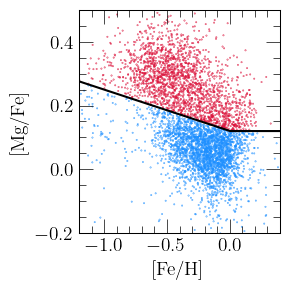

In [71]:
fig = plt.figure(figsize = (3, 3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"[Fe/H]")
ax.set_ylabel(r"[Mg/Fe]")
ax.set_xlim([-1.2, 0.4])
ax.set_ylim([-0.2, 0.5])
ax.set_xticks([-1, -0.5, 0])

kwargs = {
    "s": 0.1,
    "rasterized": True
}
indices = np.random.choice(len(dr3giants["sobject_id"]), size = 5000, replace = False)
feh = [dr3giants["fe_h"][i] for i in indices]
mgfe = [dr3giants["mg_fe"][i] for i in indices]
high_alpha = [dr3giants["highalpha"][i] for i in indices]
kwargs["c"] = [named_colors()["crimson"] if high_alpha[i] else named_colors()["dodgerblue"] for i in range(len(feh))]
ax.scatter(feh, mgfe, **kwargs)

xvals = np.linspace(*ax.get_xlim(), 1000)
yvals = [weinberg2019_alpha_separation.separation(x) for x in xvals]
ax.plot(xvals, yvals, c = named_colors()["black"])

plt.tight_layout()
plt.show()

/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_71955/447764510.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


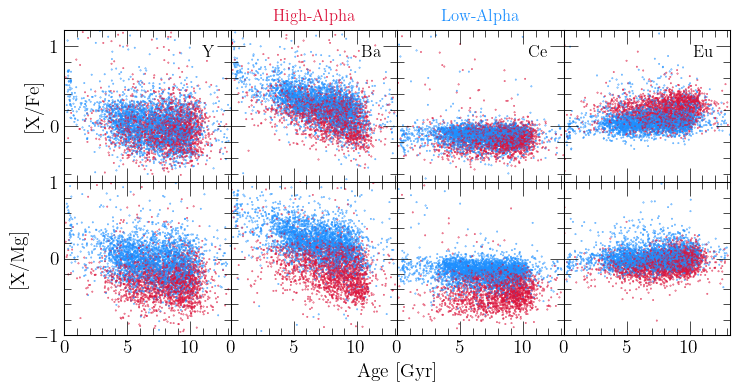

In [69]:
ELEMENTS = ["y", "ba", "ce", "eu"]
N_STARS = 5000

fig, axes = plt.subplots(nrows = 2, ncols = len(ELEMENTS), figsize = (7.5, 4), sharex = True, sharey = "row")
for i in range(len(axes)):
    for j in range(len(axes[i])):
        if j:
            plt.setp(axes[i][j].get_yticklabels(), visible = False)
        else:
            axes[i][j].set_ylabel(r"[X/%s]" % (["Fe", "Mg"][i]))
axes[0][0].set_xlim([0, 13.2])
axes[0][0].set_xticks([0, 5, 10])
axes[0][0].set_ylim([-0.7, 1.2])
axes[1][0].set_ylim([-1, 1])
dummy = fig.add_axes([0.1, 0.1, 0.1, 0.1], xticks = [], yticks = [], zorder = -1000)
dummy.set_xlabel(r"Age [Gyr]", labelpad = 20)

def plot_age_relation(ax, stars, elem, ref_elem, n_stars = N_STARS, **kwargs):
    sub = stars.filter("flag_%s_fe" % (elem), "==", 0)
    indices = np.random.choice(len(sub["sobject_id"]), size = n_stars, replace = False)
    age = [sub["age"][i] for i in indices]
    match ref_elem:
        case "fe":
            y = [sub["%s_fe" % (elem)][i] for i in indices]
        case "mg":
            y = [xfe - mgfe for xfe, mgfe in zip(sub["%s_fe" % (elem)], sub["mg_fe"])]
            y = [y[i] for i in indices]
        case _:
            raise ValueError("Reference elements must be either Mg or Fe. Got: %s" % (ref_elem))
    highalpha = [sub["highalpha"][i] for i in indices]
    colors = ["crimson" if highalpha[i] else "dodgerblue" for i in range(len(highalpha))]
    colors = [named_colors()[c] for c in colors]
    ax.scatter(age, y, c = colors, **kwargs)

stars = dr3giants.filter(
    "rgal", ">=", 7).filter(
    "rgal", "<=", 9).filter(
    "absz", "<=", 0.5)
for i in range(len(axes)):
    for j in range(len(ELEMENTS)):
        kwargs = {
            "s": 0.1,
            "rasterized": True
        }
        plot_age_relation(axes[i][j], stars, ELEMENTS[j], ["fe", "mg"][i], **kwargs)
        if not i: axes[i][j].text(
            axes[i][j].get_xlim()[0] + 0.9 * (axes[i][j].get_xlim()[1] - axes[i][j].get_xlim()[0]),
            axes[i][j].get_ylim()[0] + 0.9 * (axes[i][j].get_ylim()[1] - axes[i][j].get_ylim()[0]),
            ELEMENTS[j].capitalize(),
            horizontalalignment = "right",
            verticalalignment = "top",
            fontsize = 12)

axes[0][1].set_title("High-Alpha", fontsize = 12, color = named_colors()["crimson"])
axes[0][2].set_title("Low-Alpha", fontsize = 12, color = named_colors()["dodgerblue"])

plt.tight_layout()
plt.subplots_adjust(wspace = 0, hspace = 0, bottom = 0.15)
dummy.set_position([
    axes[-1][0].get_position().x0,
    axes[-1][0].get_position().y0,
    axes[-1][-1].get_position().x1 - axes[-1][0].get_position().x0,
    axes[0][0].get_position().y1 - axes[-1][0].get_position().y0
])
for ext in ["pdf", "jpeg"]:
    kwargs = {}
    if ext == "kwargs": kwargs["dpi"] = 200
    plt.savefig("./GALAH/xfe-xmg-age.%s" % (ext), **kwargs)
plt.show()

/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_71955/2249724756.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


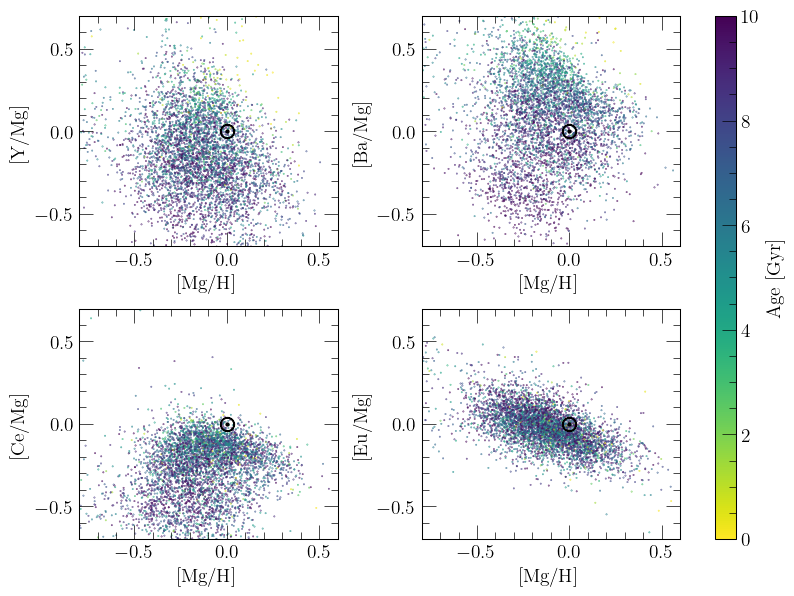

In [5]:
ELEMENTS = ["y", "ba", "ce", "eu"]
REFERENCE_ELEMENT = "mg"
COLORMAP = "viridis_r"

fig = plt.figure(figsize = (7, 6))
axes = []
for i in range(len(ELEMENTS)):
    axes.append(fig.add_subplot(221 + i))
    axes[i].set_xlabel("[%s/H]" % (REFERENCE_ELEMENT.capitalize()))
    axes[i].set_ylabel(r"[%s/%s]" % (ELEMENTS[i].capitalize(), REFERENCE_ELEMENT.capitalize()))
    axes[i].set_xlim([-0.8, 0.6])
    axes[i].set_ylim([-0.7, 0.7])

cbar_ax = fig.add_axes([0.9, 0.1, 0.1, 0.9])

stars = dr3giants.filter(
    "rgal", ">=", 7).filter(
    "rgal", "<=", 9).filter(
    "absz", "<=", 0.5)
for i in range(len(ELEMENTS)):
    sub = stars.filter("flag_%s_fe" % (ELEMENTS[i]), "==", 0)
    indices = np.random.choice(len(sub["star_id"]), size = 5000, replace = False)
    kwargs = {
        "c": [sub["age"][i] for i in indices],
        "cmap": plt.get_cmap(COLORMAP),
        "s": 0.1,
        "rasterized": True,
        "vmin": 0,
        "vmax": 10
    }
    if REFERENCE_ELEMENT == "fe":
        x = [sub["%s_h" % (REFERENCE_ELEMENT)][idx] for idx in indices]
        y = [sub["%s_%s" % (ELEMENTS[i], REFERENCE_ELEMENT)][idx] for idx in indices]
    else:
        x = [xfe + feh for xfe, feh in zip(sub["%s_fe" % (REFERENCE_ELEMENT)], sub["fe_h"])]
        x = [x[i] for i in indices]
        y = [xfe - mgfe for xfe, mgfe in zip(sub["%s_fe" % (ELEMENTS[i])], sub["mg_fe"])]
        y = [y[i] for i in indices]
    axes[i].scatter(x, y, **kwargs)
    # sc = axes[i].scatter(x, y, **kwargs)
    # axes[i].scatter(sub["%s_h" % (REFERENCE_ELEMENT)], sub["%s_%s" % (ELEMENTS[i], REFERENCE_ELEMENT)], **kwargs)

for ax in axes: ax.scatter([0], [0], marker = r"$\odot$", s = 100, color = named_colors()["black"])

cbar = plt.colorbar(sM, cax = cbar_ax, orientation = "vertical", location = "right")
cbar.set_label("Age [Gyr]")

plt.tight_layout()
cbar_ax.set_position([
    axes[-1].get_position().x1 + 0.05,
    axes[-1].get_position().y0,
    0.03,
    axes[0].get_position().y1 - axes[-1].get_position().y0
])
plt.show()

/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_41543/1443626839.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


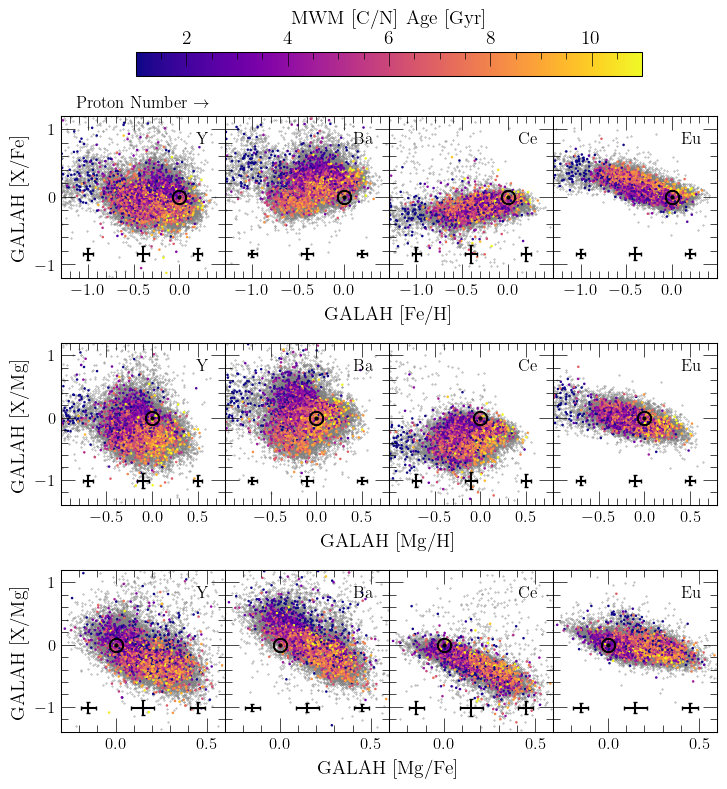

In [32]:
ELEMENTS = ["y", "ba", "ce", "eu"]
COLORMAP = "plasma"
N_STARS = 1000
ERROR_BAR_BINS = 3
VMIN = 1
VMAX = 11
np.random.seed(seed = 1)

fig, axes = plt.subplots(nrows = 3, ncols = len(ELEMENTS), figsize = (7.5, 8), sharex = "row", sharey = "row")
axes[0][0].set_ylabel(r"GALAH [X/Fe]")
axes[1][0].set_ylabel(r"GALAH [X/Mg]")
axes[2][0].set_ylabel(r"GALAH [X/Mg]")
axes[0][0].set_xlim([-1.3, 0.5])
axes[0][0].set_ylim([-1.2, 1.2])
axes[0][0].set_xticks([-1, -0.5, 0])
axes[1][0].set_xlim([-1, 0.8])
axes[1][0].set_ylim([-1.4, 1.2])
axes[1][0].set_xticks([-0.5, 0, 0.5])
axes[2][0].set_xlim([-0.3, 0.6])
axes[2][0].set_ylim([-1.4, 1.2])
# axes[2][0].set_xticks([0, 0.2, 0.4])
axes[0][0].set_title(r"Proton Number $\rightarrow$", fontsize = 12)
for i in range(len(axes)):
    for j in range(len(axes[i])):
        if j: plt.setp(axes[i][j].get_yticklabels(), visible = False)
        axes[i][j].tick_params(labelsize = 12)
        axes[i][j].text(
            axes[i][j].get_xlim()[0] + 0.9 * (axes[i][j].get_xlim()[1] - axes[i][j].get_xlim()[0]),
            axes[i][j].get_ylim()[0] + 0.9 * (axes[i][j].get_ylim()[1] - axes[i][j].get_ylim()[0]),
            ELEMENTS[j].capitalize(),
            horizontalalignment = "right",
            verticalalignment = "top",
            fontsize = 12)

dummies = []
for i in range(len(axes)):
    dummies.append(fig.add_axes([0.1, 0.1, 0.1, 0.1], xticks = [], yticks = [], zorder = -1000))
    dummies[i].set_xlabel([r"GALAH [Fe/H]", r"GALAH [Mg/H]", r"GALAH [Mg/Fe]"][i], labelpad = 20)

cbar_ax = fig.add_axes([0.1, 0.8, 0.8, 0.1])
norm = plt.Normalize(vmin = VMIN, vmax = VMAX)
sm = plt.cm.ScalarMappable(cmap = COLORMAP, norm = norm)
cmap = plt.get_cmap(COLORMAP)

def plot_abundance_pattern(ax, stars, elem, ref_elem, ages = True, **kwargs):
    if ages:
        indices = list(filter(lambda i: not np.isnan(stars["mwm_cn_age"][i]), list(range(len(stars["sobject_id"])))))
    else:
        indices = list(filter(lambda i: np.isnan(stars["mwm_cn_age"][i]), list(range(len(stars["sobject_id"])))))
    match ref_elem:
        case "fe":
            x = [stars["fe_h"][i] for i in indices]
            y = [stars["%s_fe" % (elem)][i] for i in indices]
        case "mg":
            mgfe = [stars["mg_fe"][i] for i in indices]
            feh = [stars["fe_h"][i] for i in indices]
            x = [m + f for m, f in zip(mgfe, feh)]
            y = [x - m for x, m in zip([stars["%s_fe" % (elem)][i] for i in indices], mgfe)]
        case "mgfe":
            x = [stars["mg_fe"][i] for i in indices]
            y = [x - mgfe for x, mgfe in zip([stars["%s_fe" % (elem)][i] for i in indices], x)]
        case _:
            raise ValueError("Reference element must be either Mg, Fe, or 'mgfe' for [Mg/Fe]. Got: %s" % (ref_elem))
    if ages:
        c = [cmap(norm(stars["mwm_cn_age"][i])) for i in indices]
    else:
        c = named_colors()["grey"]
    return ax.scatter(x, y, c = c, **kwargs)

def plot_uncertainties(ax, stars, elem, ref_elem, n_stars = N_STARS, **kwargs):
    x, y, _ = get_xy_vectors(stars, elem, ref_elem, n_stars = n_stars)
    bins = np.linspace(*ax.get_xlim(), ERROR_BAR_BINS + 1)
    for i in range(ERROR_BAR_BINS):
        indices = [int(bins[i] <= _ < bins[i + 1]) for _ in x]
        if ref_elem == "mgfe":
            xerr = np.median([stars["e_mg_fe"][i] for i in indices])
        else:
            xerr = np.median([stars["e_fe_h"][i] for i in indices])
        yerr = np.median([stars["e_%s_fe" % (elem)][i] for i in indices])
        ax.errorbar(
            (bins[i] + bins[i + 1]) / 2,
            ax.get_ylim()[0] + 0.15 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            xerr = xerr,
            yerr = yerr,
            **kwargs)

stars = dr3giants.filter(
    "rgal", ">=", 7).filter(
    "rgal", "<=", 9).filter(
    "absz", "<=", 0.5)
for i in range(len(axes)):
    for j in range(len(axes[i])):
        kwargs = {
            "rasterized": True
        }
        for _ in [False, True]:
            kwargs["s"] = 0.7 if _ else 0.1
            plot_abundance_pattern(axes[i][j], stars, ELEMENTS[j], ["fe", "mg", "mgfe"][i], ages = _, **kwargs)
        plot_uncertainties(axes[i][j], stars, ELEMENTS[j], ["fe", "mg", "mgfe"][i],
            c = named_colors()["black"], capsize = 1.5, alpha = 1)
        axes[i][j].scatter([0], [0], marker = r"$\odot$", s = 100, zorder = 1e6, color = named_colors()["black"])

cbar = plt.colorbar(sm, cax = cbar_ax, orientation = "horizontal", location = "top")
cbar.set_label(r"MWM [C/N] Age [Gyr]")

plt.tight_layout()
plt.subplots_adjust(wspace = 0, hspace = 0.4, bottom = 0.08, top = 0.85)
for i in range(len(dummies)):
    dummies[i].set_position([
        axes[i][0].get_position().x0,
        axes[i][0].get_position().y0,
        axes[i][-1].get_position().x1 - axes[i][0].get_position().x0,
        axes[i][0].get_position().y1 - axes[i][0].get_position().y0
    ])
cbar_ax.set_position([
    axes[0][0].get_position().x0 + 0.1,
    axes[0][0].get_position().y1 + 0.05,
    axes[0][-1].get_position().x1 - axes[0][0].get_position().x0 - 0.2,
    0.03
])
for ext in ["pdf", "jpeg"]:
    kwargs = {}
    if ext == "jpeg": kwargs["dpi"] = 200
    plt.savefig("./GALAH/x-mg-fe-age-solarannulus.%s" % (ext), **kwargs)
plt.show()